In [115]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

In [116]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(256, activation="relu")(x)
#x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
#x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_fcn")

In [117]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [118]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [119]:
history = model.fit(x_train, y_train, batch_size=64, epochs=40, validation_split=0.2)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3227 - loss: 1.8895 - val_accuracy: 0.3790 - val_loss: 1.7437
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3902 - loss: 1.7017 - val_accuracy: 0.3870 - val_loss: 1.7205
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4179 - loss: 1.6278 - val_accuracy: 0.4233 - val_loss: 1.6209
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4411 - loss: 1.5686 - val_accuracy: 0.4409 - val_loss: 1.5731
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4523 - loss: 1.5297 - val_accuracy: 0.4275 - val_loss: 1.6022
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4615 - loss: 1.5069 - val_accuracy: 0.4639 - val_loss: 1.5321
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4701 - loss: 1.4788 - val_accuracy: 0.4633 - val_loss: 1.5213
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4813 - loss: 1.4495 - val_accuracy: 0.

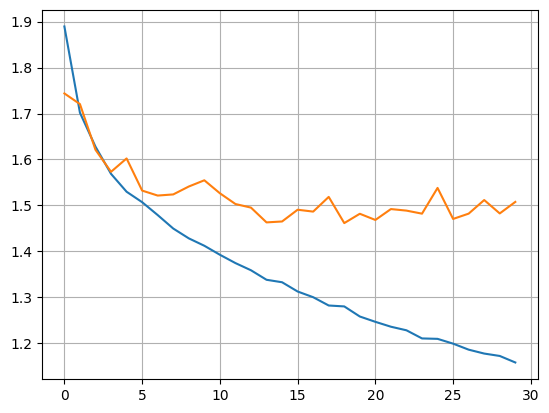

In [120]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

In [121]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

train_scores = model.evaluate(x_train, y_train, verbose=2)
print("Train loss:", train_scores[0])
print("Train accuracy:", train_scores[1])

313/313 - 1s - 3ms/step - accuracy: 0.4926 - loss: 1.4868
Test loss: 1.4867806434631348
Test accuracy: 0.4925999939441681
1563/1563 - 4s - 2ms/step - accuracy: 0.5740 - loss: 1.2082
Train loss: 1.2081706523895264
Train accuracy: 0.5740399956703186


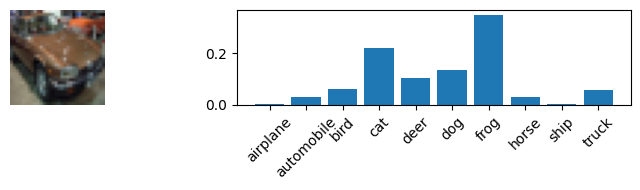

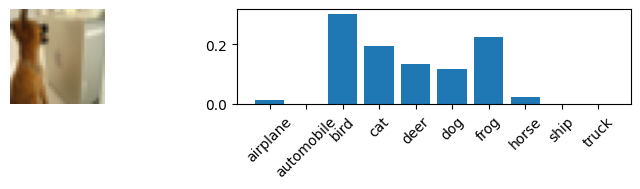

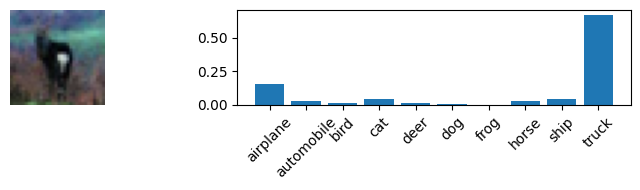

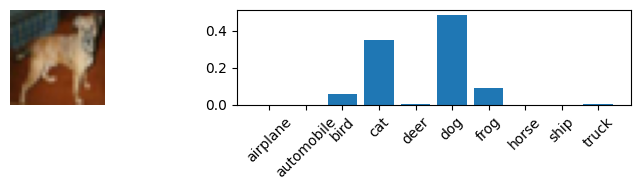

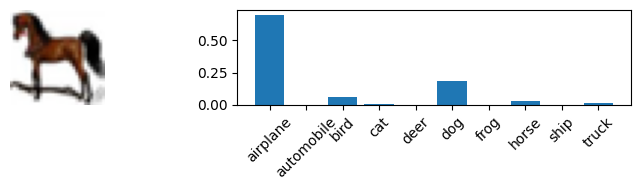

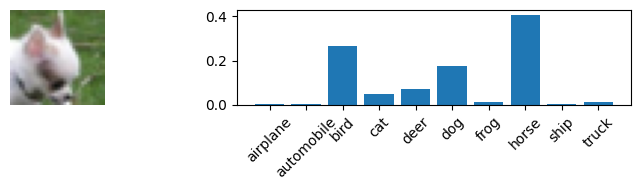

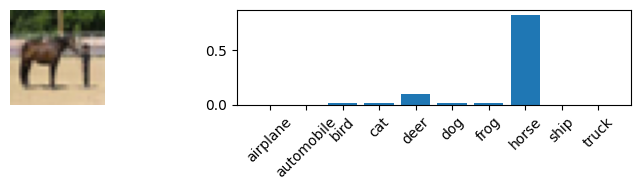

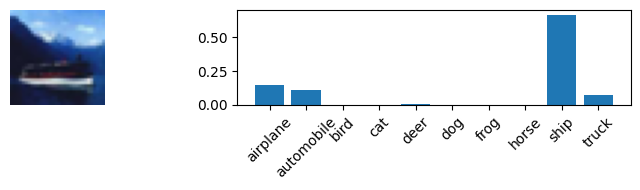

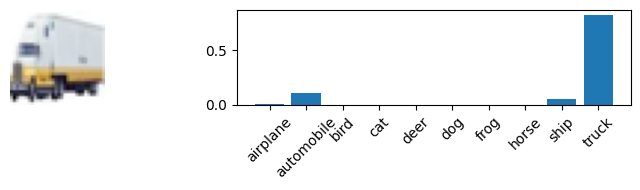

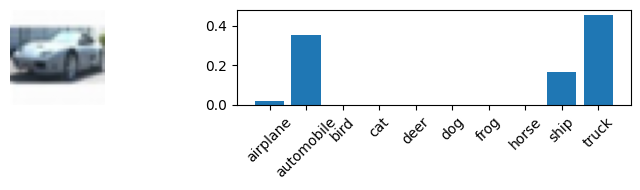

In [123]:
x = x_test
y = model(x)
start = 2000

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(x[start + k].reshape((32, 32, 3)))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    ind = np.arange(10)
    plt.bar(ind, y[start + k].numpy().flatten())

    plt.xticks(ind, class_names, rotation=45)
    plt.tight_layout()
    plt.show()